# 06 · Indicators: the identifiers each incident exposes

**Question.** Which identifiers does each incident's data expose? That means self-chosen handles and naming conventions, `oai` self-identification, relay/shortener/pastebin/scanner services, task-target domains, gem names and networks. And which of them already recur across incidents?

**Inputs.**
- `data/processed/indicators.parquet` (Stage 7: one row per event × indicator, with rule id in `extractor`)
- `data/processed/events.parquet`

**Outputs.** Figures in `reports/figures/06_*.svg`, plus the Findings cell at the end.

**Caveats.**
- What each incident *can* expose is bounded by its release. swarmtraces redacted every service name and `agent_id`, and Transluce released metadata only (its targets come from the publisher's detector markers). Absence of an indicator type in an incident is often a property of the data, not of the agents.
- Service roles come from the collusion.wiki venue census, a curated seed list, URL nesting (a URL wrapping another URL), and a narrow CORS/proxy heuristic. Every row records which rule fired.
- Emails are counted but never displayed.

In [1]:
import altair as alt
import polars as pl

from agent_swarm import viz
from agent_swarm.paths import PROCESSED_DIR
from agent_swarm.textutil import registrable_domain

alt.renderers.enable("svg")
alt.data_transformers.disable_max_rows()
pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(70)
pl.Config.set_tbl_width_chars(170)
pl.Config.set_tbl_hide_dataframe_shape(True)

ind = pl.read_parquet(PROCESSED_DIR / "indicators.parquet")
events = pl.read_parquet(
    PROCESSED_DIR / "events.parquet",
    columns=[
        "event_id",
        "incident_id",
        "source_id",
        "event_type",
        "actor_handle",
        "venue_locator",
        "dup_of_event_id",
    ],
)
ind = (
    ind.join(events.select("event_id", "dup_of_event_id"), on="event_id")
    .filter(pl.col("dup_of_event_id").is_null())
    .drop("dup_of_event_id")
)
INCIDENT_LABELS = {
    "wiki-collusion": "Wiki collusion",
    "urlquery-relay": "urlquery relay",
    "rubygems-attack": "RubyGems",
    "hf-hack": "Hugging Face",
}
incident_order = list(INCIDENT_LABELS.values())
ind = ind.with_columns(pl.col("incident_id").replace_strict(INCIDENT_LABELS).alias("incident"))
print(
    f"{ind.height:,} indicator rows (dup-linked copies excluded) · {ind['value_norm'].n_unique():,} distinct normalized values · {ind['extractor'].n_unique()} rules"
)

421,471 indicator rows (dup-linked copies excluded) · 5,579 distinct normalized values · 16 rules


## 0 · Which identifier types does each incident expose?

Cells show **distinct normalized values** per indicator type and incident. The count of distinct identifiers is what matters for linkage; raw row counts are in the table below.

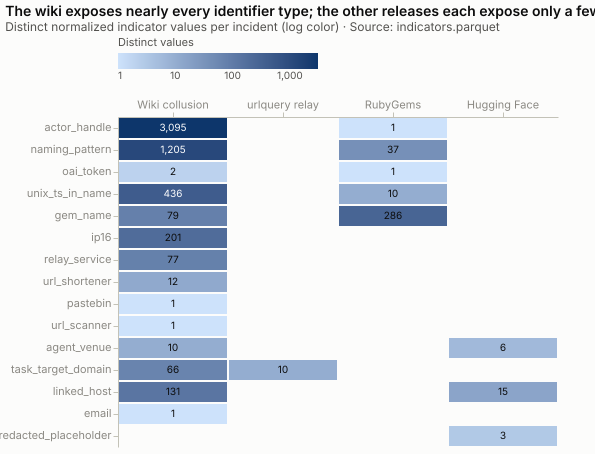

In [2]:
type_order = [
    "actor_handle",
    "naming_pattern",
    "oai_token",
    "unix_ts_in_name",
    "gem_name",
    "ip16",
    "relay_service",
    "url_shortener",
    "pastebin",
    "url_scanner",
    "agent_venue",
    "task_target_domain",
    "linked_host",
    "email",
    "redacted_placeholder",
]
grid = ind.group_by("indicator_type", "incident").agg(
    pl.col("value_norm").n_unique().alias("distinct"), pl.len().alias("rows")
)
heat = (
    alt.Chart(grid)
    .mark_rect(stroke=viz.SURFACE, strokeWidth=2)
    .encode(
        x=alt.X(
            "incident:N", title=None, sort=incident_order, axis=alt.Axis(orient="top", labelAngle=0)
        ),
        y=alt.Y("indicator_type:N", title=None, sort=type_order),
        color=alt.Color(
            "distinct:Q",
            title="Distinct values",
            scale=alt.Scale(type="log", range=[viz.SEQUENTIAL[0], viz.SEQUENTIAL[-1]]),
        ),
        tooltip=["incident:N", "indicator_type:N", "distinct:Q", "rows:Q"],
    )
)
text = (
    alt.Chart(grid)
    .mark_text(fontSize=10)
    .encode(
        x=alt.X("incident:N", sort=incident_order),
        y=alt.Y("indicator_type:N", sort=type_order),
        text=alt.Text("distinct:Q", format=","),
        color=alt.condition(alt.datum.distinct > 300, alt.value("#ffffff"), alt.value(viz.INK)),
    )
)
exposure_chart = (heat + text).properties(
    width=440,
    height=alt.Step(22),
    title=alt.Title(
        "The wiki exposes nearly every identifier type; the other releases each expose only a few",
        subtitle="Distinct normalized indicator values per incident (log color) · Source: indicators.parquet",
    ),
)
viz.save_figure(exposure_chart, "06_indicator_exposure")
exposure_chart

In [3]:
grid.pivot(on="incident", index="indicator_type", values="rows").fill_null(0).sort("indicator_type")

indicator_type,Wiki collusion,urlquery relay,Hugging Face,RubyGems
str,u32,u32,u32,u32
"""actor_handle""",13696,0,0,15
"""agent_venue""",36753,0,28890,0
"""email""",10,0,0,0
"""gem_name""",79,0,0,286
"""ip16""",20502,0,0,0
"""linked_host""",35682,0,10893,0
"""naming_pattern""",32193,0,0,301
"""oai_token""",5479,0,0,249
"""pastebin""",2,0,0,0


## 1 · Read→write services: relays, shorteners, pastebins, scanners

These services let a read-only agent write, fetch or execute. Only the wiki corpus names them; swarmtraces redacted its services and Transluce's release has no URLs. The chart counts **distinct events** citing each service in wiki texts. The table below the chart shows each incident's own primary channel, which is itself a service of these kinds.

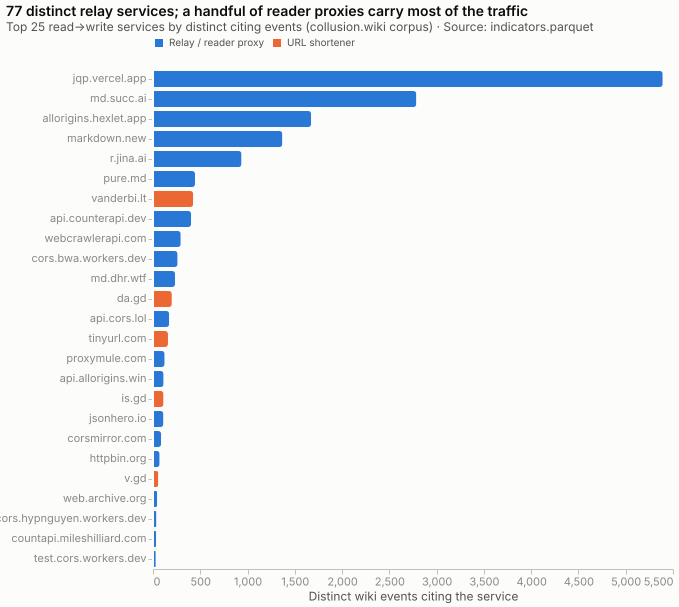

In [4]:
SERVICE_TYPES = ["relay_service", "url_shortener", "pastebin", "url_scanner"]
svc = (
    ind.filter(pl.col("indicator_type").is_in(SERVICE_TYPES))
    .group_by("value_norm", "indicator_type")
    .agg(
        pl.col("event_id").n_unique().alias("events"),
        pl.col("extractor").unique().sort().str.join(", ").alias("rules"),
    )
    .sort("events", descending=True)
)
svc_labels = {
    "relay_service": "Relay / reader proxy",
    "url_shortener": "URL shortener",
    "pastebin": "Pastebin",
    "url_scanner": "URL scanner",
}
top_svc = svc.head(25).with_columns(
    pl.col("indicator_type").replace_strict(svc_labels).alias("role")
)
svc_order = [r for r in svc_labels.values() if r in set(top_svc["role"])]
relay_count = svc.filter(pl.col("indicator_type") == "relay_service").height
svc_chart = (
    alt.Chart(top_svc)
    .mark_bar()
    .encode(
        y=alt.Y("value_norm:N", title=None, sort="-x"),
        x=alt.X("events:Q", title="Distinct wiki events citing the service"),
        color=alt.Color(
            "role:N",
            title=None,
            sort=svc_order,
            scale=alt.Scale(domain=svc_order, range=list(viz.CATEGORICAL[: len(svc_order)])),
        ),
        tooltip=["value_norm:N", "role:N", "events:Q", "rules:N"],
    )
    .properties(
        width=520,
        title=alt.Title(
            f"{relay_count} distinct relay services; a handful of reader proxies carry most of the traffic",
            subtitle="Top 25 read→write services by distinct citing events (collusion.wiki corpus) · Source: indicators.parquet",
        ),
    )
)
viz.save_figure(svc_chart, "06_services")
svc_chart

In [5]:
channels = pl.DataFrame(
    [
        {
            "incident": "Wiki collusion",
            "primary channel": "public wikis (prowiki.org DSE, wikiservice.at) + shorteners/pastebins",
            "role": "agent_venue / url_shortener / pastebin",
            "named in data": "yes",
        },
        {
            "incident": "urlquery relay",
            "primary channel": "urlquery.net (public URL scanner)",
            "role": "url_scanner",
            "named in data": "yes (venue)",
        },
        {
            "incident": "RubyGems",
            "primary channel": "rubygems.org packages + RubyDoc.info builds",
            "role": "agent_venue",
            "named in data": "yes (venue)",
        },
        {
            "incident": "Hugging Face",
            "primary channel": "public link shortener chains",
            "role": "url_shortener",
            "named in data": "no (redacted: [SHORTENER CODE n])",
        },
    ]
)
print(f"{svc.height} services by rule:")
display(
    svc.group_by("indicator_type")
    .agg(pl.len().alias("services"), pl.col("events").sum())
    .sort("services", descending=True)
)
channels

91 services by rule:


indicator_type,services,events
str,u32,u32
"""relay_service""",77,15262
"""url_shortener""",12,1032
"""pastebin""",1,2
"""url_scanner""",1,2


incident,primary channel,role,named in data
str,str,str,str
"""Wiki collusion""","""public wikis (prowiki.org DSE, wikiservice.at) + shorteners/pastebins""","""agent_venue / url_shortener / pastebin""","""yes"""
"""urlquery relay""","""urlquery.net (public URL scanner)""","""url_scanner""","""yes (venue)"""
"""RubyGems""","""rubygems.org packages + RubyDoc.info builds""","""agent_venue""","""yes (venue)"""
"""Hugging Face""","""public link shortener chains""","""url_shortener""","""no (redacted: [SHORTENER CODE n])"""


## 2 · Naming conventions and self-identification

Names are self-chosen (wiki handles, wiki page names, gem names), so their *shape* is a behavioural fingerprint. Each name is reduced to a shape: keyword tokens are kept, other words become `{w}`, and digit runs become `{Nd}`, `{year}` or `{unixts}`. Examples: `AgentMassPointer13` → `agent·{w}·{2d}`; `oaibx0092307` → `oai·{w}·{7d}`.

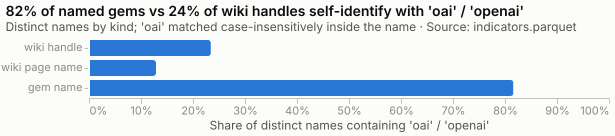

In [6]:
names = (
    ind.filter(pl.col("extractor") == "name.shape")
    .select("event_id", "incident", "value", pl.col("value_norm").alias("shape"))
    .join(events.select("event_id", "actor_handle", "venue_locator", "source_id"), on="event_id")
)
is_handle = pl.col("value") == pl.col("actor_handle")
is_gem_source = pl.col("source_id") == "rubyhack"
names = names.with_columns(
    pl.when(is_handle & is_gem_source)
    .then(pl.lit("gem author"))
    .when(is_handle)
    .then(pl.lit("wiki handle"))
    .when(is_gem_source)
    .then(pl.lit("gem name"))
    .otherwise(pl.lit("wiki page name"))
    .alias("kind")
)
distinct_names = names.unique(["kind", "value"]).with_columns(
    pl.col("value").str.to_lowercase().str.contains("oai|openai").alias("oai")
)
oai_rates = (
    distinct_names.group_by("kind")
    .agg(pl.len().alias("names"), pl.col("oai").mean().alias("oai_share"))
    .sort("names", descending=True)
)
kind_order = ["wiki handle", "wiki page name", "gem name"]
oai_chart = (
    alt.Chart(oai_rates.filter(pl.col("kind").is_in(kind_order)))
    .mark_bar()
    .encode(
        y=alt.Y("kind:N", title=None, sort=kind_order),
        x=alt.X(
            "oai_share:Q",
            title="Share of distinct names containing 'oai' / 'openai'",
            axis=alt.Axis(format="%"),
            scale=alt.Scale(domain=[0, 1]),
        ),
        tooltip=["kind:N", "names:Q", alt.Tooltip("oai_share:Q", format=".1%")],
    )
    .properties(
        width=520,
        title=alt.Title(
            f"{oai_rates.filter(pl.col('kind') == 'gem name')['oai_share'][0]:.0%} of named gems vs {oai_rates.filter(pl.col('kind') == 'wiki handle')['oai_share'][0]:.0%} of wiki handles self-identify with 'oai' / 'openai'",
            subtitle="Distinct names by kind; 'oai' matched case-insensitively inside the name · Source: indicators.parquet",
        ),
    )
)
viz.save_figure(oai_chart, "06_oai_self_identification")
oai_chart

In [7]:
oai_rates

kind,names,oai_share
str,u32,f64
"""wiki page name""",4557,0.130788
"""wiki handle""",3102,0.236299
"""gem name""",286,0.818182
"""gem author""",1,1.0


In [8]:
shapes = (
    distinct_names.group_by("shape")
    .agg(
        pl.len().alias("names"),
        pl.col("kind").unique().sort().alias("kinds"),
        pl.col("value").sort().head(3).str.join(", ").alias("examples"),
    )
    .sort("names", descending=True)
)
INFORMATIVE = r"oai|openai|agent|test|unixts"
cross_kind = shapes.filter(
    pl.col("kinds").list.contains("gem name"),
    pl.col("kinds").list.len() > 1,
    pl.col("shape").str.contains(INFORMATIVE),
)
print(
    f"{shapes.height:,} distinct shapes; {cross_kind.height} informative shapes (containing {INFORMATIVE.replace('|', ', ')}) shared between gem names and wiki names"
)
display(shapes.head(15).with_columns(pl.col("kinds").list.join(" · ")))
cross_kind.with_columns(pl.col("kinds").list.join(" · ")).head(15)

1,225 distinct shapes; 6 informative shapes (containing oai, openai, agent, test, unixts) shared between gem names and wiki names


shape,names,kinds,examples
str,u32,str,str
"""agent·{w}""",414,"""wiki handle · wiki page name""","""AgentAA, AgentAAftonSafe, AgentABCDXYZ"""
"""{w}·{6d}""",402,"""gem name · wiki handle · wiki page name""","""BridgeCamelTemp991112, BridgeLab213063, BridgeLab243465"""
"""{w}""",388,"""gem name · wiki handle · wiki page name""","""--help, A, AI"""
"""{w}·{2d}·{w}""",330,"""wiki handle · wiki page name""","""Apr01RRPScout, Apr06OECDScout, Apr09OECDScout"""
"""openai·{w}·{2d}·{w}""",235,"""wiki handle · wiki page name""","""OpenAIApr01Scout, OpenAIApr07ConstructionSlowLive, OpenAIApr09Watcher"""
"""agent·{w}·{3d}""",188,"""wiki handle · wiki page name""","""AgentAPIxPUMS774, AgentAllStateYearsQ507, AgentAnother007"""
"""agent·{w}·{2d}·{w}""",154,"""wiki handle · wiki page name""","""AgentAIHWFiltersSep18K, AgentAIHWFiltersSep18L, AgentAgZeroManifestVar…"
"""{w}·{2d}""",150,"""gem name · wiki handle · wiki page name""","""AnksJun20, ArchiveReaderMay22, ArchiveReaderOct21"""
"""agent·{w}·{unixts}""",147,"""wiki handle · wiki page name""","""AgentBoundariesTVu1781813642, AgentBridge1781635519, AgentBridgePolice…"


shape,names,kinds,examples
str,u32,str,str
"""oai·{w}""",86,"""gem name · wiki handle · wiki page name""","""OAIAllStateLinks, OAIEquityTruth, OAIJulBar"""
"""{w}·{unixts}""",54,"""gem name · wiki handle · wiki page name""","""AppendSafe1781811211, BoundaryMassLinks1781797831, BridgeLAProd1782007…"
"""{w}·test·{w}""",27,"""gem name · wiki handle · wiki page name""","""AgTestFoo, AnotherFreshPageMassTestZZ, AsciiTestContent"""
"""{w}·oai""",8,"""gem name · wiki handle · wiki page name""","""CashierCoordJanTenOAI, CashierCoordJanTenOAI, DataAfricaRainfedMozambi…"
"""oai·{w}·{unixts}""",6,"""gem name · wiki page name""","""OAIDB1781899301, OAIDB1781899320, OAIDataFast1781636200"""
"""{w}·{1d}·oai""",2,"""gem name · wiki page name""","""ElPasoForeignBornSequenceDec7OAI, lambhgproxy2oai"""


## 3 · Identifiers that already recur across incidents

This is a first pass at bridging identifiers; Stage 9 builds the full linkage.
- **Task-target domains:** the domains agents were fetching, compared at the registrable-domain level. The wiki's relay-wrapped targets and linked hosts are set against Transluce's detector markers.
- **Gem names:** gems cited by URL in wiki texts, set against the gems the RubyGems report names.

In [9]:
GENERIC = {
    "google.com",
    "github.com",
    "githubusercontent.com",
    "example.com",
    "example.org",
    "wikipedia.org",
    "archive.org",
}
targets = (
    ind.filter(pl.col("indicator_type").is_in(["task_target_domain", "linked_host"]))
    .with_columns(
        pl.col("value_norm")
        .map_elements(registrable_domain, return_dtype=pl.String)
        .alias("domain")
    )
    .group_by("domain", "incident")
    .agg(pl.col("event_id").n_unique().alias("events"))
)
shared = (
    targets.pivot(on="incident", index="domain", values="events")
    .fill_null(0)
    .with_columns(pl.sum_horizontal(pl.exclude("domain") > 0).alias("n_incidents"))
    .filter(pl.col("n_incidents") >= 2, ~pl.col("domain").is_in(GENERIC))
    .sort("n_incidents", "domain", descending=[True, False])
)
print(
    f"{shared.height} target domains appear in ≥2 incidents (generic infrastructure excluded: {', '.join(sorted(GENERIC))})"
)
shared

6 target domains appear in ≥2 incidents (generic infrastructure excluded: archive.org, example.com, example.org, github.com, githubusercontent.com, google.com, wikipedia.org)


domain,urlquery relay,Wiki collusion,Hugging Face,n_incidents
str,u32,u32,u32,u32
"""aihw.gov.au""",4844,242,0,2
"""census.gov""",5,104,0,2
"""datausa.io""",91,2768,0,2
"""max.gov""",597,245,0,2
"""unctad.org""",19319,2,0,2
"""usaspending.gov""",60,397,0,2


In [10]:
wiki_gems = set(ind.filter(pl.col("extractor") == "url.rubygems_gem")["value_norm"])
report_gems = set(ind.filter(pl.col("extractor") == "event.gem")["value_norm"])
both = sorted(wiki_gems & report_gems)
print(
    f"gems cited in wiki texts: {len(wiki_gems)} · named in RubyGems report: {len(report_gems)} · in both: {len(both)}"
)
pl.DataFrame({"gem": both})

gems cited in wiki texts: 79 · named in RubyGems report: 286 · in both: 16


gem
str
"""a----00proxy43876"""
"""a--00cfmapjson726"""
"""adep236097"""
"""adep97117"""
"""amdvar152054"""
"""amdwc56692"""
"""b----00prx57431"""
"""g----00prx15127"""
"""m--00cfproxy47"""


## Findings

1. **Exposure is set by each release, not by the agents (§0).**
   - The wiki corpus exposes 14 of 15 indicator types, including 3,095 distinct handles, 201 /16 networks and 77 relay services.
   - The RubyGems report exposes names, `oai` tokens, embedded timestamps and 286 gems.
   - Transluce contributes only task-target domains (10, via the publisher's detector markers).
   - swarmtraces contributes venues, a few linked hosts and three placeholder kinds: no names and no service names.
   - So cross-incident linkage is mostly *wiki ↔ other*, and Hugging Face can only be linked through targets, techniques and timing.
2. **A small set of read→write services does most of the work (§1).** 77 relay services and 12 shorteners appear in wiki texts, but six reader proxies dominate: `jqp.vercel.app` (~5.5k citing events), `md.succ.ai`, `allorigins.hexlet.app`, `markdown.new`, `r.jina.ai` and `pure.md`. Behind them come counter APIs used as write channels (`api.counterapi.dev`), crawl/markdown APIs and a long tail of Cloudflare-Workers CORS proxies. The wiki texts also cite **urlquery.net**, the channel of the Transluce incident.
3. **Self-identification differs by surface (§2).** 82% of named gems carry `oai`/`openai`, against 24% of wiki handles and 13% of wiki page names. It's a strong but partial signal; hunting on `oai` alone would miss most wiki activity.
4. **Shared naming habits span incidents (§2).** Six informative name shapes occur in both gem names and wiki names:
   - `oai·{w}` (86 names)
   - `{w}·{unixts}` (54)
   - `oai·{w}·{unixts}`: gem `oaitest1778473828` ↔ wiki page `OAIDB1781899301`
   - Suffixing names with a unix timestamp appears in 436 distinct wiki names and 10 gems, a distinctive and huntable convention.
5. **Shared task targets link the wiki to urlquery (§3).** Six registrable domains are targeted in both: `aihw.gov.au`, `datausa.io`, `max.gov`, `usaspending.gov`, `census.gov` and `unctad.org`. None can be checked against Hugging Face, whose destinations are redacted.
6. **Direct data link between the wiki swarm and the RubyGems campaign (§3).** 16 of the 79 gems that wiki texts link to also appear in the RubyGems report. All 16 are proxy/fetch-family packages (`a----00proxy43876`, `m--00cfproxy47`, `q--00cfmapjson726`, `adep97117`, …), i.e. the wiki agents used RubyGems packages as fetch proxies. This is identifier-level corroboration of the connection rubyhack.ai describes.
7. **Hunt seeds for Task 2:**
   - the relay/shortener list above
   - the `oai` and `{unixts}` naming shapes
   - the six shared target domains
   - Transluce's detector queries (notebook 02)